### Chapter 5. Cognitive Architectures with LangGraph

<li>The key trade-off often faced when building LLM apps: the trade-off between  <b>agency</b> (or the capacity to act autonomously) and <b>reliability</b> (or the degree to which you can trust its outputs). </li>

One way to describe the degree of autonomy of an LLM application is to evaluate how much of the behavior of the application is determined by an LLM (versus code):

<li>One way to describe the degree of autonomy of an LLM application is to evaluate how much of the behavior of the application is determined by an LLM (versus code) </li>

<li>Have an LLM decide the next step to take (for instance, for a new email, decide between the three actions it can take on an email: archive, reply, or mark for review).</li>

<li>Have an LLM decide what steps are available to take (for instance, have the LLM write code that executes a dynamic action you didn’t preprogram into the application).</li>

We can classify a number of popular recipes for building LLM applications based on where they fall in this spectrum of autonomy, that is, which of the three tasks just mentioned are handled by an LLM and which remain in the hands of the developer or user. These recipes can be called **cognitive architectures**.


### Architecture #1: LLM Call


In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
GoogleGeminiKey = os.getenv('GOOGLE_GEMINI_KEY')

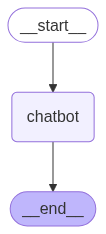

In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-001",
    api_key=GoogleGeminiKey,
)


class State(TypedDict):
    messages: Annotated[list, add_messages]


def chatbot(state: State):
    response = model.invoke(state["messages"])
    # return {"messages": state["messages"] + [{"role":"assistant", "content":response}]}
    return {"messages": [response]}


builder = StateGraph(State)
builder.add_node('chatbot', chatbot)
builder.add_edge(START, 'chatbot')
builder.add_edge('chatbot', END)
graph = builder.compile()
graph

In [ ]:
from langchain_core.messages import HumanMessage
input_message = {"messages": [HumanMessage(content="Hello, how are you?")]}

graph.invoke(input_message)

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='1754d84a-b7dd-4c41-84db-ad46fb732221'),
  AIMessage(content="I am doing well, thank you for asking! As a large language model, I don't experience emotions or feelings in the same way humans do, but I am functioning optimally and ready to assist you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001', 'safety_ratings': []}, id='run--837462e2-4429-4e6f-9d77-ba21d47bce26-0', usage_metadata={'input_tokens': 6, 'output_tokens': 50, 'total_tokens': 56, 'input_token_details': {'cache_read': 0}})]}

### Architecture #2: Chain

This next architecture extends on all that by using multiple LLM calls, in a predefined sequence (that is, different invocations of the application do the same sequence of LLM calls, albeit with different inputs and results).

First let’s describe the flow in words:

1. One LLM call to generate a SQL query from the natural language query, provided by the user, and a description of the database contents, provided by the developer.

2. Another LLM call to write an explanation of the query appropriate for a nontechnical user, given the query generated in the previous call. This one could then be used to enable the user to check if the generated query matches his request.


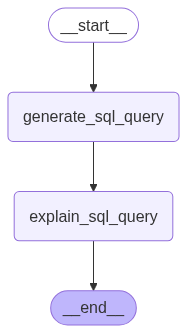

In [ ]:
from typing import Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage

# models

model_low_temp = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-001",
    api_key=GoogleGeminiKey,
    temperature=0.1,
)

model_high_temp = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-001",
    api_key=GoogleGeminiKey,
    temperature=0.75,
)

# States


class State(TypedDict):
    messages: Annotated[list, add_messages]
    # input
    user_query: str

    # output
    sql_query: str
    sql_explanation: str


class Input(TypedDict):
    user_query: str


class Output(TypedDict):
    sql_query: str
    sql_explanation: str


# prompts
query_gen_prompt = SystemMessage(
    content="You are a SQL query generator. You will generate a SQL query based on the given input.")
sql_query_explain_prompt = SystemMessage(
    content="You are an SQL query explanation generator. You will explain the generated SQL query in detail.")

# nodes


def generate_sql_query(state: State) -> State:
    q = HumanMessage(content=state['user_query'])
    res = model_low_temp.invoke([query_gen_prompt, *state['messages'], q])
    return {
        "sql_query": res.content,
        "messages": [q, res]
    }


def explain_sql_query(state: State) -> State:
    res = model_high_temp.invoke(
        [sql_query_explain_prompt, *state['messages']])
    return {
        "sql_explanation": res.content,
        "messages": res
    }


builder = StateGraph(State, input_schema=Input, output_schema=Output)

builder.add_node("generate_sql_query", generate_sql_query)
builder.add_node("explain_sql_query", explain_sql_query)

builder.add_edge(START, 'generate_sql_query')
builder.add_edge('generate_sql_query', 'explain_sql_query')
builder.add_edge('explain_sql_query', END)

graph = builder.compile()
graph

In [ ]:
res = graph.invoke({
    "user_query": "What is the total sales for each product?"
})

print(f"SQL Query: {res['sql_query']}")
print(f"Explanation: {res['sql_explanation']}")

SQL Query: ```sql
SELECT
    product_name,
    SUM(sales) AS total_sales
FROM
    sales_table
GROUP BY
    product_name;
```
Explanation: 
**Explanation:**

1.  **SELECT product\_name, SUM(sales) AS total\_sales:**
    *   This part specifies what columns to retrieve.
    *   `product_name`:  Selects the name of the product.
    *   `SUM(sales) AS total_sales`: Calculates the sum of the `sales` column for each product and aliases the result as `total_sales`.  The `SUM()` function is an aggregate function that computes the total.

2.  **FROM sales\_table:**
    *   This indicates that the data is being retrieved from a table named `sales_table`.  You would replace `sales_table` with the actual name of your table containing sales data.  This table *must* have columns named (or aliased to) `product_name` and `sales`.

3.  **GROUP BY product\_name:**
    *   This is the crucial part for calculating sales *per product*.
    *   The `GROUP BY` clause groups rows that have the same `product_n

### Architecture #3: Router


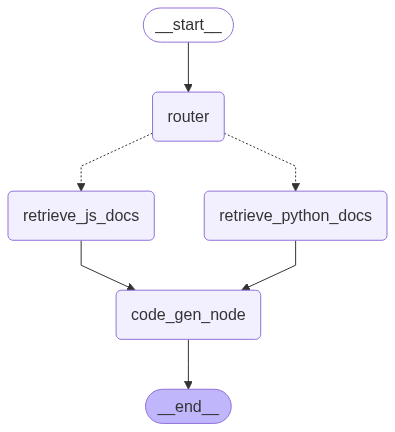

In [34]:
from typing import Literal
from pydantic import BaseModel, Field

from langchain_core.documents import Document
from langchain.vectorstores import FAISS
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_core.messages import HumanMessage,SystemMessage


from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/embedding-001", google_api_key=GoogleGeminiKey)

python_langchain_docs_store_path = "documents_store_index"
js_langchain_docs_store_path = "document_store_index_js"

python_vector_store = FAISS.load_local(folder_path=python_langchain_docs_store_path,embeddings=embeddings,index_name="index",allow_dangerous_deserialization=True)
js_vector_store = FAISS.load_local(folder_path=js_langchain_docs_store_path,embeddings=embeddings,index_name="index",allow_dangerous_deserialization=True)


# results  = python_vector_store.similarity_search(
#     "How to use install lang chain",
#     k=2,
# )

# for res in results:
#     print(f"* {res.page_content} [{res.metadata}]")

query_route_system_message = SystemMessage("""
you are an expert query router that routes user queries to the most relevant datasource based on the question. 
Based on the programming language the question is referring to, route to the most relevant datasource.

If the question not mention in which programming language, default to python. 
""")

class QueryRoute(BaseModel):
    "Route a user query to the most relevant datasource"
    data_source:Literal["python","js"]  = Field(...,description="Given a user question, Choose which datasource is most relevant to the question")

with_structural_output = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001",api_key=GoogleGeminiKey, temperature=0).with_structured_output(QueryRoute)

query_route_prompt_template = ChatPromptTemplate.from_messages([
    query_route_system_message,
    ("user",'{user_query}'),
])

router_chain = query_route_prompt_template | with_structural_output

# router_chain.invoke({"user_query": "What is the difference between a list and an array in Python?"})

def router_node(State:State) -> State:
    """Route the query to the most relevant datasource"""
    query = State["user_query"]
    res = router_chain.invoke({"user_query": query})
    return {
        "data_source": res.data_source,
        # "messages":[HumanMessage(query), res]
    }

def pick_retriever(State:State) -> Literal['retrieve_python_docs','retrieve_js_docs']:
    if(State['data_source'] == 'python'):
        return 'retrieve_python_docs'
    elif(State['data_source'] == 'js'):
        return 'retrieve_js_docs'

def retrieve_python_docs(State:State) -> State:
    """Retrieve the relevant document from the python_docs database"""
    query = State["user_query"]
    documents = python_vector_store.similarity_search(
               query,
                k=5,
            )
    return {
        "documents": documents,
    }


def retrieve_js_docs(State:State) -> State:
    """Retrieve the relevant document from the js database"""
    query = State["user_query"]
    documents = python_vector_store.similarity_search(
                query,
                k=5,
            )
    return {
        "documents": documents,
    }


sys_prompt = """
You are an expert programming assistance and generate accurate code by reading documentation and example code.
and summarizing it by joining all the pieces of code into a single coherent piece of code.
And also provide the explanation of the code.
Generate result in markdown format.
if you there is no document available the say: I do not have any references Buy from by knowledge it can be done in that way and add your solution.
"""

code_prompt = ChatPromptTemplate.from_messages([
    ("system", sys_prompt),
    ("user",
     "Provide the code in {data_source} and explanation. For the user query: {query} from the following documentation: {documents}")
])

code_llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash-001",
                         api_key=GoogleGeminiKey, temperature=0.7)

code_chain = code_prompt | code_llm

def generate_code(State:State) -> State:
    """Generate the code based on the retrieved document"""
    documents = State["documents"]
    query = State["user_query"]
    data_source = State["data_source"]
    code = code_chain.invoke({"query": query, "data_source": data_source, "documents": documents})

    return {
        "answer": code.content,
        "messages":code
    }

class State(TypedDict):
    messages: Annotated[list,add_messages]

    user_query:str

    documents:list[Document]
    answer:str
    data_source:str

class Input(TypedDict):
    user_query:str

class Output(TypedDict):
    answer:str
    messages:list[Document]


builder = StateGraph(State,input_schema=Input,output_schema=Output)

builder.add_node("router",router_node)
builder.add_node("retrieve_js_docs",retrieve_js_docs)
builder.add_node("retrieve_python_docs",retrieve_python_docs)
builder.add_node("code_gen_node",generate_code)

builder.add_edge(START,"router")
builder.add_conditional_edges("router",pick_retriever)
builder.add_edge("retrieve_js_docs","code_gen_node")
builder.add_edge("retrieve_python_docs","code_gen_node")
builder.add_edge("code_gen_node",END)

graph = builder.compile()
graph



In [38]:
input = {
    "user_query": "How to create rag chain app with lang chain in js?"
}

res = graph.invoke(input)

In [39]:
from IPython.display import Markdown, display
display(Markdown(res['answer']))

# for i in res['docs']:
#     print(i.metadata['source'])


```javascript
//Install the necessary packages
//npm install langchain langchain-community langchainhub beautifulsoup4
//npm install langchain-openai

import { ChatOpenAI } from "@langchain/openai";
import { OpenAIEmbeddings } from "@langchain/openai";
import { InMemoryVectorStore } from "langchain/vectorstores/memory";
import { WebBaseLoader } from "langchain/document_loaders/web_base";
import { RecursiveCharacterTextSplitter } from "langchain/text_splitters";
import * as cheerio from "cheerio";
import { PromptTemplate } from "@langchain/core/prompts";
import {
  RunnablePassthrough,
  RunnableSequence,
} from "@langchain/core/runnables";

// Load blog content
const loader = new WebBaseLoader(
  "https://lilianweng.github.io/posts/2023-06-23-agent/",
  {
    selector: ".post-content, .post-title, .post-header",
  }
);

const docs = await loader.load();

// Split the documents into chunks
const textSplitter = new RecursiveCharacterTextSplitter({
  chunkSize: 1000,
  chunkOverlap: 200,
});
const allSplits = await textSplitter.splitDocuments(docs);

// Initialize the LLM
const llm = new ChatOpenAI({
  modelName: "gpt-3.5-turbo",
  temperature: 0,
});

// Initialize embeddings and vector store
const embeddings = new OpenAIEmbeddings({ modelName: "text-embedding-ada-002" });
const vectorStore = await InMemoryVectorStore.fromDocuments(
  allSplits,
  embeddings
);

// Create a retrieval chain
const prompt = PromptTemplate.fromTemplate(
  `Answer the question based only on the following context:
  {context}

  Question: {question}`
);

const retriever = vectorStore.asRetriever();

const chain = RunnableSequence.from([
  {
    context: retriever.pipe((documents) => {
      return documents.map((doc) => doc.pageContent).join("\n");
    }),
    question: new RunnablePassthrough(),
  },
  prompt,
  llm,
]);

// Ask a question
const question = "What is Task Decomposition?";
const answer = await chain.invoke(question);
console.log(answer);
```

### Explanation:

1.  **Install Packages:** The code starts by listing the necessary packages and how to install them using `npm`.
2.  **Import Modules:** It imports the required modules from the `langchain` library, including `ChatOpenAI` for the language model, `OpenAIEmbeddings` for creating embeddings, `InMemoryVectorStore` for storing and retrieving vectors, `WebBaseLoader` for loading web content, `RecursiveCharacterTextSplitter` for splitting text, and `PromptTemplate` and `RunnableSequence` for creating the chain.
3.  **Load Blog Content:** It uses `WebBaseLoader` to load the content from the specified blog post URL. The `selector` option is used to extract only the relevant parts of the page (post content, title, and header).
4.  **Split Documents:** The loaded documents are split into smaller chunks using `RecursiveCharacterTextSplitter`. This helps in processing large documents and improves the accuracy of the RAG system.
5.  **Initialize LLM:**  `ChatOpenAI` is initialized with a specified model name (`gpt-3.5-turbo`) and temperature.
6.  **Initialize Embeddings and Vector Store:**  `OpenAIEmbeddings` is used to create embeddings for the document chunks. An `InMemoryVectorStore` is created to store these embeddings, allowing for efficient similarity searches.
7.  **Create Retrieval Chain:**
    *   A `PromptTemplate` is created to define the prompt that will be sent to the language model. The prompt includes a context and a question.
    *   A retriever is created from the `vectorStore` using `vectorStore.asRetriever()`.
    *   A `RunnableSequence` is created to define the chain of operations. The chain consists of the following steps:
        *   Retrieving relevant documents from the vector store based on the question.
        *   Joining the content of the retrieved documents into a single string.
        *   Passing the context and question to the prompt.
        *   Sending the prompt to the language model.
8.  **Ask a Question:** Finally, the code defines a question and uses the `chain.invoke()` method to get the answer from the RAG system. The answer is then logged to the console.

This code provides a basic implementation of a RAG chain in JavaScript using LangChain. It can be further extended and customized to suit specific requirements, such as using different language models, embedding models, vector stores, or prompt templates.